# USO DE REDES NEURONALES CONVOLUCIONALES(CNN) CON PYTORCH

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# USAREMOS DATASET MNIST

In [2]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])

train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset = datasets.MNIST(root='./data',train=False,download=True,transform=transform)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 23.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 639kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.58MB/s]


# EXPLORAMOS MNIST VISUALIZANDO ALGUNAS IMAGENES

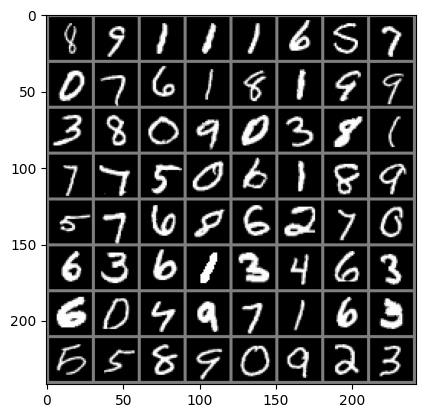

Etiquetas:
8
8 9 1 1 1 6 5 7
0 7 6 1 8 1 9 9
3 8 0 9 0 3 8 1
7 7 5 0 6 1 8 9
5 7 6 8 6 2 7 0
6 3 6 1 3 4 6 3
6 0 4 9 7 1 6 3
5 5 8 9 0 9 2 3


In [3]:
dataiter = iter(train_loader)
images,labels = next(dataiter)

def imshow(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.show()

imshow(torchvision.utils.make_grid(images))
print('Etiquetas:')
print(labels[0].item())
for i in range(0, len(labels), 8):
    print(' '.join(f'{labels[j].item()}' for j in range(i, min(i+8, len(labels)))))

## CREAMOS NUESTRA RED NEURONAL CONVOLUCIONAL CON PYTORCH

In [4]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()
    #creamos primera capa convolucional: toma una imagen y produce 16 mapas de caracteristicas
    self.conv1 = nn.Conv2d(in_channels=1,out_channels=16,kernel_size=5,stride=1,padding=2)
    #creamos una segunda capa convolucional : toma 16 mapas de caracteristicas y produce 32 mapas de caracteristicas
    self.conv2 = nn.Conv2d(in_channels=16,out_channels=32,kernel_size=5,stride=1,padding=2)
    #creamos capa FC : aplana las caracteristicas 32x7x7 a un gector y produce 32 unidades
    self.fc1 = nn.Linear(32*7*7,32)
    #creamos capa FC : toma 32 unidades y produce 10 unidades
    self.fc2 = nn.Linear(32,10)

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.max_pool2d(x,2,2)
    x = F.relu(self.conv2(x))
    x = F.max_pool2d(x,2,2)
    x = torch.flatten(x,start_dim=1)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x

# CONFIGURAMOS NUESTRA RED CNN

In [5]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)

# ENTRENAMOS NUESTRA RED NEURONAL CNN

In [6]:
n_epochs = 10
for epoch in range(n_epochs):
  running_loss = 0.0
  for images,labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f'Epoch {epoch+1}, Loss : {running_loss/len(train_loader)}')

Epoch 1, Loss : 0.1503135596333977
Epoch 2, Loss : 0.07660017504543835
Epoch 3, Loss : 0.07406512187413887
Epoch 4, Loss : 0.06989983606122699
Epoch 5, Loss : 0.06527430289119955
Epoch 6, Loss : 0.06305465786658569
Epoch 7, Loss : 0.05988551326066303
Epoch 8, Loss : 0.06465089627784733
Epoch 9, Loss : 0.06814932142044475
Epoch 10, Loss : 0.05873253589774814


# EVALUAMOS LA RED NEURONAL CNN

In [7]:
correct = 0
total = 0

with torch.no_grad():
  for images,labels in test_loader:
    outputs = model(images)
    _,predicted = torch.max(outputs.data,1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'correctos : {correct}')
print(f'total : {total}')

correctos : 9770
total : 10000


# VISUALIZAMOS LOS RESULTADOS DE ALGUNAS PREDICCIONES

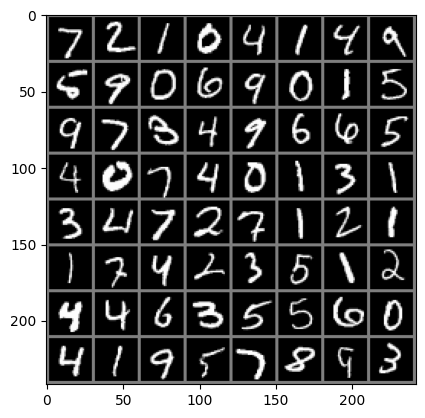

Predicted:
7 2 1 0 4 1 4 9
5 9 0 6 9 0 1 5
9 7 3 4 9 6 6 5
4 0 7 4 0 1 3 1
3 4 7 2 7 1 2 1
1 7 4 2 3 5 1 2
4 4 6 3 5 5 6 0
4 1 9 5 7 8 9 3
GroundTruth:
7 2 1 0 4 1 4 9
5 9 0 6 9 0 1 5
9 7 3 4 9 6 6 5
4 0 7 4 0 1 3 1
3 4 7 2 7 1 2 1
1 7 4 2 3 5 1 2
4 4 6 3 5 5 6 0
4 1 9 5 7 8 9 3


In [8]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

imshow(torchvision.utils.make_grid(images))

print('Predicted:')
for i in range(0, len(predicted), 8):
    print(' '.join(f'{predicted[j].item()}' for j in range(i, min(i + 8, len(predicted)))))

print('GroundTruth:')
for i in range(0, len(labels), 8):
    print(' '.join(f'{labels[j].item()}' for j in range(i, min(i + 8, len(labels)))))

# CREAMOS MATRIZ DE CONFUSIÓN

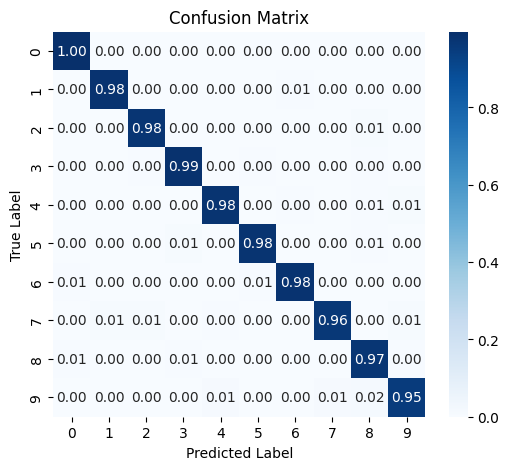

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      0.98      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Configurar el modelo en modo evaluación
model.eval()

# Listas para almacenar etiquetas reales y predichas
all_preds = []
all_labels = []

# Desactivar gradientes (inferencia)
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # Obtener la clase con mayor probabilidad
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Crear la matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Normalizar por filas (opcional)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Visualizar con Seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Reporte de clasificación
print(classification_report(all_labels, all_preds))